# Visualisation of the different climate model realizations

In [2]:
#load libraries
import importlib
import pandas as pd
import xarray as xr
import numpy as np
import datetime as dt
from numpy import nan
from constants import *
import sys
import warnings
import math
import os
import cftime
from glob import glob
from timeit import default_timer as timer # try to measure time

In [3]:
#Colors
blue_dark = "#1f4e79"
blue_main = "#2a6f97"
blue_light = "#61a5c2"
blue_very_light = "#74a9cf"
grey = "#6c757d"

## Load hazard data

In [11]:
bias_corr_hist_1 = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/bias_corr_historical_1')
bias_corr_hist_2 = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/bias_corr_historical_2')
bias_corr_hist_4 = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/bias_corr_historical_4')

bias_corr_hist_84_14_1 = bias_corr_hist_1.sel(valid_time=slice("1984-01-01", "2014-12-31"))
bias_corr_hist_84_14_2 = bias_corr_hist_2.sel(valid_time=slice("1984-01-01", "2014-12-31"))
bias_corr_hist_84_14_4 = bias_corr_hist_4.sel(valid_time=slice("1984-01-01", "2014-12-31"))

bias_corr_ssp585_1 = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/bias_corr_ssp585_1')
bias_corr_ssp585_2 = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/bias_corr_ssp585_2')
bias_corr_ssp585_4 = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/bias_corr_ssp585_4')

bias_corr_ssp585_70_100_1 = bias_corr_ssp585_1.sel(valid_time=slice("2070-01-01", "2100-12-31"))
bias_corr_ssp585_70_100_2 = bias_corr_ssp585_2.sel(valid_time=slice("2070-01-01", "2100-12-31"))
bias_corr_ssp585_70_100_4 = bias_corr_ssp585_4.sel(valid_time=slice("2070-01-01", "2100-12-31"))

bias_corr_hist_1_MPI_ESM = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/MPI-ESM21-2-LR_bias_corr_historical_1')
bias_corr_hist_2_MPI_ESM = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/MPI-ESM21-2-LR_bias_corr_historical_2')
bias_corr_hist_4_MPI_ESM = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/MPI-ESM21-2-LR_bias_corr_historical_4')

bias_corr_hist_84_14_1_MPI_ESM = bias_corr_hist_1_MPI_ESM.sel(valid_time=slice("1984-01-01", "2014-12-31"))
bias_corr_hist_84_14_2_MPI_ESM = bias_corr_hist_2_MPI_ESM.sel(valid_time=slice("1984-01-01", "2014-12-31"))
bias_corr_hist_84_14_4_MPI_ESM = bias_corr_hist_4_MPI_ESM.sel(valid_time=slice("1984-01-01", "2014-12-31"))

bias_corr_ssp585_1_MPI_ESM  = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/MPI-ESM21-2-LR_bias_corr_ssp585_1')
bias_corr_ssp585_2_MPI_ESM  = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/MPI-ESM21-2-LR_bias_corr_ssp585_2')
bias_corr_ssp585_4_MPI_ESM  = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/MPI-ESM21-2-LR_bias_corr_ssp585_4')

bias_corr_ssp585_70_100_1_MPI_ESM  = bias_corr_ssp585_1_MPI_ESM.sel(valid_time=slice("2070-01-01", "2100-12-31"))
bias_corr_ssp585_70_100_2_MPI_ESM  = bias_corr_ssp585_2_MPI_ESM .sel(valid_time=slice("2070-01-01", "2100-12-31"))
bias_corr_ssp585_70_100_4_MPI_ESM  = bias_corr_ssp585_4_MPI_ESM .sel(valid_time=slice("2070-01-01", "2100-12-31"))

bias_corr_hist_1_MRI_ESM_2_0 = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/MRI-ESM-2-0_bias_corr_historical_1')
bias_corr_hist_2_MRI_ESM_2_0= xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/MRI-ESM-2-0_bias_corr_historical_2')
bias_corr_hist_4_MRI_ESM_2_0 = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/MRI-ESM-2-0_bias_corr_historical_4')

bias_corr_hist_84_14_1_MRI_ESM_2_0 = bias_corr_hist_1_MRI_ESM_2_0.sel(valid_time=slice("1984-01-01", "2014-12-31"))
bias_corr_hist_84_14_2_MRI_ESM_2_0 = bias_corr_hist_2_MRI_ESM_2_0.sel(valid_time=slice("1984-01-01", "2014-12-31"))
bias_corr_hist_84_14_4_MRI_ESM_2_0 = bias_corr_hist_4_MRI_ESM_2_0.sel(valid_time=slice("1984-01-01", "2014-12-31"))

bias_corr_ssp585_1_MRI_ESM_2_0  = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/MRI-ESM-2-0_bias_corr_ssp585_1')
bias_corr_ssp585_2_MRI_ESM_2_0  = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/MRI-ESM-2-0_bias_corr_ssp585_2')
bias_corr_ssp585_4_MRI_ESM_2_0  = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/MRI-ESM-2-0_bias_corr_ssp585_4')

bias_corr_ssp585_70_100_1_MRI_ESM_2_0  = bias_corr_ssp585_1_MRI_ESM_2_0.sel(valid_time=slice("2070-01-01", "2100-12-31"))
bias_corr_ssp585_70_100_2_MRI_ESM_2_0  = bias_corr_ssp585_2_MRI_ESM_2_0.sel(valid_time=slice("2070-01-01", "2100-12-31"))
bias_corr_ssp585_70_100_4_MRI_ESM_2_0  = bias_corr_ssp585_4_MRI_ESM_2_0.sel(valid_time=slice("2070-01-01", "2100-12-31"))

bias_corr_hist_1_EARTH = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/EARTH_bias_corr_historical_1')
bias_corr_hist_2_EARTH = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/EARTH_bias_corr_historical_3')
bias_corr_hist_4_EARTH  = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/EARTH_bias_corr_historical_4')

bias_corr_hist_84_14_1_EARTH  = bias_corr_hist_1_EARTH.sel(valid_time=slice("1984-01-01", "2014-12-31"))
bias_corr_hist_84_14_2_EARTH  = bias_corr_hist_2_EARTH.sel(valid_time=slice("1984-01-01", "2014-12-31"))
bias_corr_hist_84_14_4_EARTH  = bias_corr_hist_4_EARTH.sel(valid_time=slice("1984-01-01", "2014-12-31"))

bias_corr_ssp585_1_EARTH   = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/EARTH_bias_corr_ssp585_1')
bias_corr_ssp585_2_EARTH   = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/EARTH_bias_corr_ssp585_3')
bias_corr_ssp585_4_EARTH   = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/EARTH_bias_corr_ssp585_4')

bias_corr_ssp585_70_100_1_EARTH   = bias_corr_ssp585_1_EARTH.sel(valid_time=slice("2070-01-01", "2100-12-31"))
bias_corr_ssp585_70_100_2_EARTH   = bias_corr_ssp585_2_EARTH.sel(valid_time=slice("2070-01-01", "2100-12-31"))
bias_corr_ssp585_70_100_4_EARTH   = bias_corr_ssp585_4_EARTH.sel(valid_time=slice("2070-01-01", "2100-12-31"))

## Prepare data for visulations

In [12]:
hist_list = [
     (bias_corr_hist_84_14_1_MPI_ESM, "MPI-ESM1.2-LR r1"),
    (bias_corr_hist_84_14_2_MPI_ESM, "MPI-ESM1.2-LR r2"),
    (bias_corr_hist_84_14_4_MPI_ESM, "MPI-ESM1.2-LR r4"),
    (bias_corr_hist_84_14_2, "CNRM-CM6 r1"),
    (bias_corr_hist_84_14_2, "CNRM-CM6 r2"),
    (bias_corr_hist_84_14_4, "CNRM-CM6 r4"),
    (bias_corr_hist_84_14_1_MRI_ESM_2_0, "MRI-ESM2.0 r1"),
    (bias_corr_hist_84_14_2_MRI_ESM_2_0, "MRI-ESM2.0 r2"),
    (bias_corr_hist_84_14_4_MRI_ESM_2_0, "MRI-ESM2.0 r4"),
    (bias_corr_hist_84_14_1_EARTH, "EC-EARTH3 r1"),
    (bias_corr_hist_84_14_2_EARTH, "EC-EARTH3 r3"),
    (bias_corr_hist_84_14_4_EARTH, "EC-EARTH3 r4"),
]

In [18]:
df_list = []

for ds, model_name in hist_list:
    df = ds.to_dataframe().reset_index()
    df['scenario'] = 'historical'
    df['model'] = model_name
    df_list.append(df)

#Combine all model DataFrames into one dataset
df_hist = pd.concat(df_list, ignore_index=True)

In [14]:
ssp_list = [
    (bias_corr_ssp585_70_100_1_MPI_ESM, "MPI-ESM1.2-LR r1"),
    (bias_corr_ssp585_70_100_2_MPI_ESM, "MPI-ESM1.2-LR r2"),
    (bias_corr_ssp585_70_100_4_MPI_ESM, "MPI-ESM1.2-LR r4"),
    (bias_corr_ssp585_70_100_1, "CNRM-CM6 r1"),
    (bias_corr_ssp585_70_100_2, "CNRM-CM6 r2"),
    (bias_corr_ssp585_70_100_4, "CNRM-CM6 r4"),
    (bias_corr_ssp585_70_100_1_MRI_ESM_2_0, "MRI-ESM2.0 r1"),
    (bias_corr_ssp585_70_100_2_MRI_ESM_2_0, "MRI-ESM2.0 r2"),
    (bias_corr_ssp585_70_100_4_MRI_ESM_2_0, "MRI-ESM2.0 r4"),
    (bias_corr_ssp585_70_100_1_EARTH, "EC-EARTH3 r1"),
    (bias_corr_ssp585_70_100_2_EARTH, "EC-EARTH3 r3"),
    (bias_corr_ssp585_70_100_4_EARTH, "EC-EARTH3 r4"),
]

df_list_ssp = []

for ds, model_name in ssp_list:
    df = ds.to_dataframe().reset_index()
    df['scenario'] = 'ssp585'
    df['model'] = model_name
    df_list_ssp.append(df)

df_ssp = pd.concat(df_list_ssp, ignore_index=True)

In [19]:
#Combine all model DataFrames into one dataset
df_all = pd.concat([df_hist, df_ssp], ignore_index=True)
#Only keep the extreme wind speeds
df_clean = df_all[df_all['historical'] >= 22.22]

## Plot Boxplot

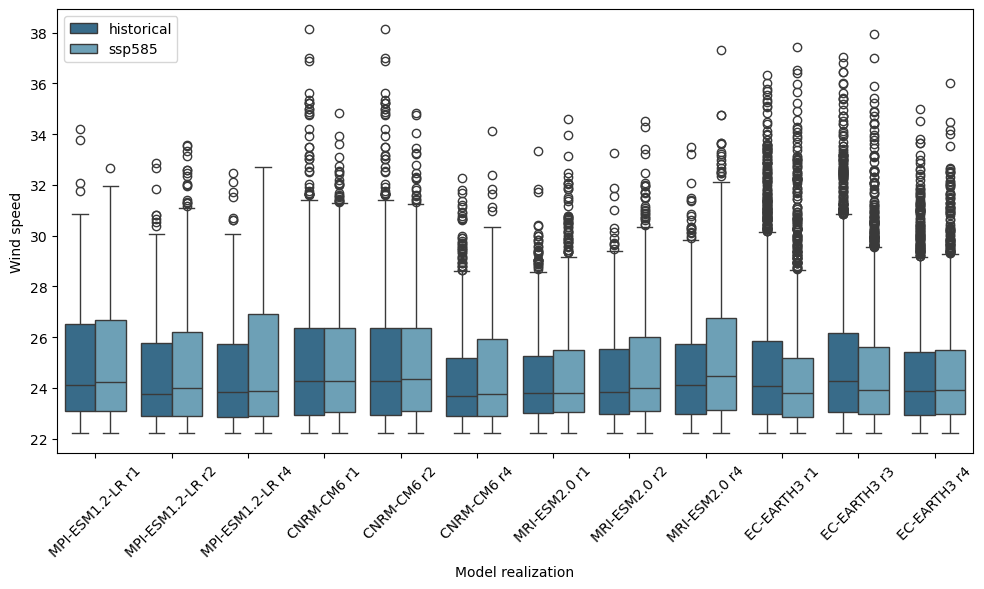

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x='model',
    y='historical',
    hue='scenario',
    palette={'historical': blue_main, 'ssp585': blue_light},
)


plt.legend(loc='upper left', bbox_to_anchor=(0, 1))
plt.ylabel("Wind speed")
plt.xlabel("Model realization")

plt.xticks(rotation=45)
plt.tight_layout()

#Save boxplot
plt.savefig("/Users/anne-sophiesimons/Documents/Data thesis/boxplots", dpi=300)
plt.show()